<a href="https://colab.research.google.com/github/LuisMesa10/DeepLearning/blob/main/RETO_1_3SCENES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =========================================================
# OBJETIVO:
# Implementar una versión corregida y mejor documentada del
# modelo base de clasificación de 3 escenas:
#   - coast
#   - forest
#   - highway
#
# En esta primera fase NO se modifica la arquitectura CNN.
# Se mejora el experimento en términos de:
#   1) reproducibilidad
#   2) separación adecuada train / validation / test
#   3) evaluación matemática y gráfica
#
# Esto servirá como línea base sólida para comparar luego
# con una CNN mejorada y con una arquitectura no secuencial.
# =========================================================

# =========================================================
# 1. IMPORTACIONES
# =========================================================

import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from google.colab import drive

from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Activation, Flatten, Dense
from tensorflow.keras.optimizers import Adam


In [2]:
# =========================================================
# 2. MONTAJE DE GOOGLE DRIVE
# =========================================================

drive.mount('/content/drive')


Mounted at /content/drive


In [3]:

# =========================================================
# 3. CONFIGURACIÓN GENERAL Y SEMILLAS
# =========================================================
# Fijamos semillas para hacer el experimento reproducible.
# Esto ayuda a que la partición de datos y varios procesos
# aleatorios sean consistentes entre ejecuciones.

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Ruta base del dataset
base_path = '/content/drive/MyDrive/3scenes'

# Nombres de las carpetas (cada carpeta representa una clase)
subfolders = ['coast', 'forest', 'highway']

# Tamaño al que se redimensionarán todas las imágenes
IMG_SIZE = (128, 128)

In [4]:
# =========================================================
# 4. CARGA Y PREPROCESAMIENTO DE IMÁGENES
# =========================================================
# En este bloque:
#   - recorremos cada carpeta
#   - leemos imágenes JPG
#   - las redimensionamos a 128x128
#   - normalizamos los pixeles a [0, 1]
#   - guardamos la imagen y su etiqueta

data = []
labels = []

for subfolder in subfolders:
    current_folder_path = os.path.join(base_path, subfolder)

    # Verificamos que la carpeta exista
    if not os.path.exists(current_folder_path):
        raise FileNotFoundError(f"No se encontró la carpeta: {current_folder_path}")

    files = [f for f in os.listdir(current_folder_path) if f.lower().endswith('.jpg')]

    for file in files:
        img_path = os.path.join(current_folder_path, file)

        # Lectura de la imagen
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)

        # Si la imagen no pudo cargarse, se omite
        if img is None:
            print(f"Advertencia: no se pudo leer {img_path}")
            continue

        # Redimensionar primero
        img = cv2.resize(img, IMG_SIZE)

        # Convertir a float32 y normalizar a [0, 1]
        img = img.astype('float32') / 255.0

        data.append(img)
        labels.append(subfolder)

# Convertimos a arreglos de NumPy
data = np.array(data, dtype='float32')
labels = np.array(labels)

print("Cantidad total de imágenes:", len(data))
print("Forma del arreglo de imágenes:", data.shape)
print("Cantidad total de etiquetas:", len(labels))

# Mostrar cuántas imágenes hay por clase
print("\nDistribución por clase:")
for clase in subfolders:
    print(f"{clase}: {np.sum(labels == clase)}")

Cantidad total de imágenes: 958
Forma del arreglo de imágenes: (958, 128, 128, 3)
Cantidad total de etiquetas: 958

Distribución por clase:
coast: 360
forest: 328
highway: 270


In [5]:
# =========================================================
# 5. CODIFICACIÓN DE ETIQUETAS
# =========================================================
# Convertimos las etiquetas de texto a formato one-hot.
# Ejemplo:
#   coast   -> [1,0,0]
#   forest  -> [0,1,0]
#   highway -> [0,0,1]

lb = LabelBinarizer()
labels_encoded = lb.fit_transform(labels)

print("\nClases detectadas por LabelBinarizer:")
print(lb.classes_)


Clases detectadas por LabelBinarizer:
['coast' 'forest' 'highway']


In [6]:
# =========================================================
# 6. DIVISIÓN TRAIN / VALIDATION / TEST
# =========================================================
# Queremos una separación más correcta que en el notebook original.
#
# Estrategia:
#   Paso 1: separar 20% para test
#   Paso 2: del 80% restante, separar 25% para validation
#
# Resultado final:
#   Train      = 60%
#   Validation = 20%
#   Test       = 20%
#
# Además usamos stratify para conservar proporciones por clase.

# Primer split: train_val y test
trainValX, testX, trainValY, testY, trainValLabels, testLabels = train_test_split(
    data,
    labels_encoded,
    labels,  # etiquetas originales para estratificar e interpretar
    test_size=0.20,
    random_state=SEED,
    stratify=labels
)

# Segundo split: train y validation
trainX, valX, trainY, valY, trainLabels, valLabels = train_test_split(
    trainValX,
    trainValY,
    trainValLabels,
    test_size=0.25,   # 25% de 80% = 20% del total
    random_state=SEED,
    stratify=trainValLabels
)

print("\nTamaños finales:")
print("Train:", trainX.shape, trainY.shape)
print("Validation:", valX.shape, valY.shape)
print("Test:", testX.shape, testY.shape)


Tamaños finales:
Train: (574, 128, 128, 3) (574, 3)
Validation: (192, 128, 128, 3) (192, 3)
Test: (192, 128, 128, 3) (192, 3)


In [7]:
# =========================================================
# 7. CONSTRUCCIÓN DEL MODELO BASE (SIN MODIFICAR ARQUITECTURA)
# =========================================================
# Mantenemos la misma arquitectura del profesor:
#   Conv(8)  -> ReLU -> MaxPool
#   Conv(16) -> ReLU -> MaxPool
#   Conv(32) -> ReLU -> MaxPool
#   Flatten  -> Dense(3) -> Softmax
#
# Única mejora formal aquí:
# usamos Input() de forma explícita para evitar el warning.

model = Sequential([
    Input(shape=(128, 128, 3)),

    Conv2D(8, (3, 3), padding="same"),
    Activation("relu"),
    MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    Conv2D(16, (3, 3), padding="same"),
    Activation("relu"),
    MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    Conv2D(32, (3, 3), padding="same"),
    Activation("relu"),
    MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

    Flatten(),
    Dense(3),
    Activation("softmax")
])

print("\nResumen del modelo:")
model.summary()



Resumen del modelo:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │        24,579 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 3)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,611 (119.57 KB)

 Trainable params: 30,611 (119.57 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# =========================================================
# 8. COMPILACIÓN DEL MODELO
# =========================================================
# Usamos Adam con learning rate fijo 1e-3.
# NO usamos el parámetro decay porque en versiones recientes
# de Keras ya no se soporta y sería ignorado.

opt = Adam(learning_rate=1e-3)

model.compile(
    loss="categorical_crossentropy",
    optimizer=opt,
    metrics=["accuracy"]
)

In [9]:
# =========================================================
# 9. ENTRENAMIENTO
# =========================================================
# Ahora sí usamos validation_data correctamente sobre valX, valY
# y reservamos testX/testY para la evaluación final.

EPOCHS = 15
BATCH_SIZE = 32

history = model.fit(
    trainX, trainY,
    validation_data=(valX, valY),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 391ms/step - accuracy: 0.3798 - loss: 1.0601 - val_accuracy: 0.6250 - val_loss: 0.9320
Epoch 2/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 435ms/step - accuracy: 0.7422 - loss: 0.7914 - val_accuracy: 0.7083 - val_loss: 0.5880
Epoch 3/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 308ms/step - accuracy: 0.7666 - loss: 0.5424 - val_accuracy: 0.8958 - val_loss: 0.3830
Epoch 4/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 302ms/step - accuracy: 0.8624 - loss: 0.4190 - val_accuracy: 0.8542 - val_loss: 0.3921
Epoch 5/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 411ms/step - accuracy: 0.8780 - loss: 0.3637 - val_accuracy: 0.8854 - val_loss: 0.3016
Epoch 6/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 301ms/step - accuracy: 0.8937 - loss: 0.3011 - val_accuracy: 0.9010 - val_loss: 0.2682
Epoch 7/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 454ms/step - accuracy: 0.9111 - loss: 0.2789 - val_accuracy: 0.8958 - val_loss: 0.2849
Epoch 8/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 295ms/step - accuracy: 0.9181 - loss: 0.2599 - val_accuracy: 0

In [10]:
# =========================================================
# 10. EVALUACIÓN FINAL EN TEST
# =========================================================
# Este bloque se ejecuta solo al final, usando el conjunto
# de prueba que no participó durante el entrenamiento.

pred_probs = model.predict(testX, batch_size=BATCH_SIZE)
pred_classes = pred_probs.argmax(axis=1)
true_classes = testY.argmax(axis=1)

test_acc = accuracy_score(true_classes, pred_classes)

print("\nAccuracy final en TEST:", round(test_acc, 4))

print("\nReporte de clasificación en TEST:")
print(classification_report(
    true_classes,
    pred_classes,
    target_names=lb.classes_
))

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step

Accuracy final en TEST: 0.9271

Reporte de clasificación en TEST:
              precision    recall  f1-score   support

       coast       0.91      0.89      0.90        72
      forest       1.00      0.98      0.99        66
     highway       0.86      0.91      0.88        54

    accuracy                           0.93       192
   macro avg       0.92      0.93      0.93       192
weighted avg       0.93      0.93      0.93       192



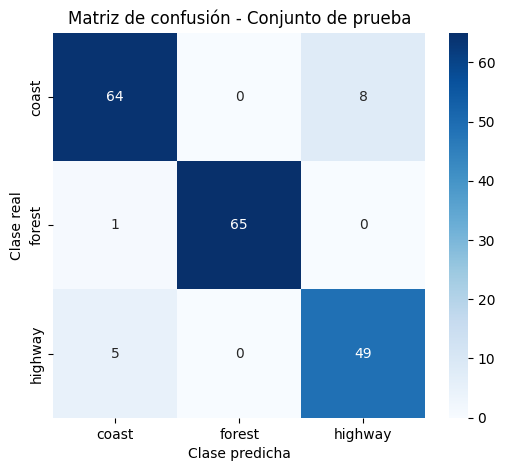

In [11]:
# =========================================================
# 11. MATRIZ DE CONFUSIÓN
# =========================================================
# La matriz de confusión permite ver en qué clases se equivoca
# más el modelo y entre cuáles ocurre la confusión.

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=lb.classes_,
    yticklabels=lb.classes_
)
plt.title('Matriz de confusión - Conjunto de prueba')
plt.xlabel('Clase predicha')
plt.ylabel('Clase real')
plt.show()


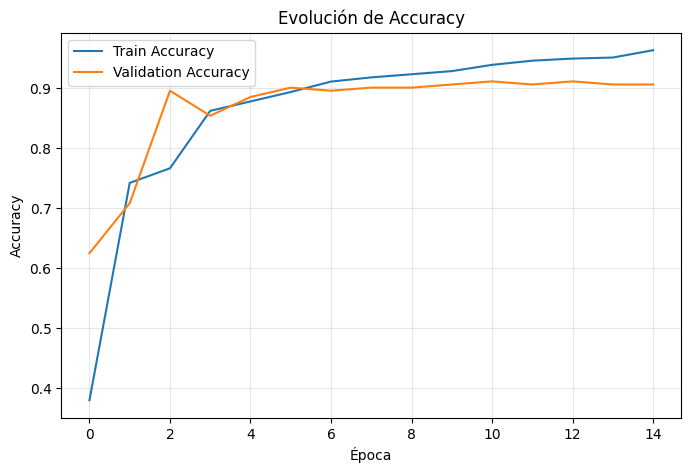

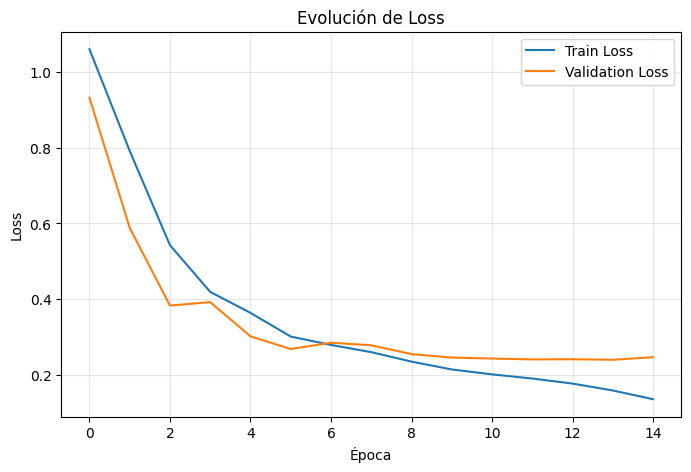

In [12]:
# =========================================================
# 12. CURVAS DE ENTRENAMIENTO
# =========================================================
# Graficamos cómo evolucionan accuracy y loss tanto en train
# como en validation.

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Evolución de Accuracy')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Evolución de Loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

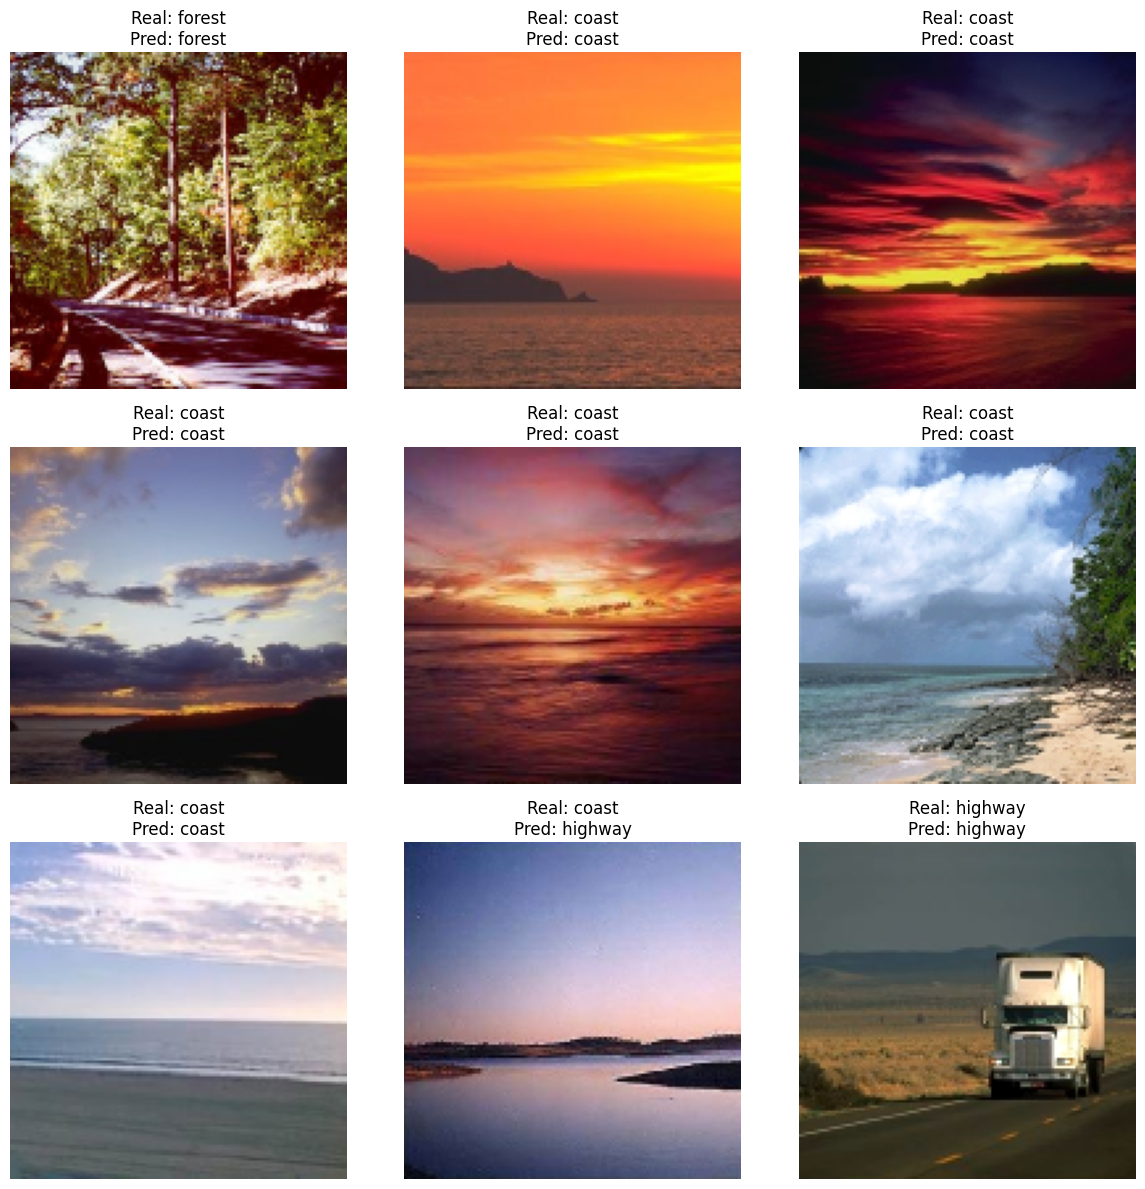

In [13]:
# =========================================================
# 13. VISUALIZACIÓN DE ALGUNAS PREDICCIONES
# =========================================================
# Mostramos algunas imágenes del conjunto de prueba con:
#   - clase real
#   - clase predicha
# Esto ayuda a interpretar cualitativamente los resultados.

num_samples = 9
indices = np.random.choice(len(testX), size=min(num_samples, len(testX)), replace=False)

plt.figure(figsize=(12, 12))

for i, idx in enumerate(indices, 1):
    img = testX[idx]
    true_label = lb.classes_[true_classes[idx]]
    pred_label = lb.classes_[pred_classes[idx]]

    # OpenCV carga en BGR, pero matplotlib muestra en RGB
    # Para visualización, convertimos BGR -> RGB
    img_rgb = cv2.cvtColor((img * 255).astype('uint8'), cv2.COLOR_BGR2RGB)

    plt.subplot(3, 3, i)
    plt.imshow(img_rgb)
    plt.title(f"Real: {true_label}\nPred: {pred_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()